# 5.2 Hydrocarbons on Platinum

In [1]:
from ecp.style import header, use_style

use_style()
header(
    volume="Volume V — Crystals and Surfaces",
    number="5.2",
    title="Hydrocarbons on Platinum",
    blurb="How tightly a molecule sticks to a metal surface, and why the answer depends "
    "so much on the density functional: benzene, methane, and ethane on Pt(111), where "
    "the van der Waals attraction that binds them is exactly what plain functionals "
    "miss.",
    difficulty="intermediate",
    estimate="75–100 min",
    source="FS 2023 · Lecture 8 (adsorption and dispersion)",
)

<ECP header: 2830 chars of HTML>

## Notebook overview

Platinum is the workhorse of catalysis, and catalysis begins with **adsorption**: a
molecule must stick to the surface before it can react. How strongly it sticks, the
**adsorption energy**, is the single most important number, and for hydrocarbons on a
metal it is dominated by **van der Waals** (dispersion) attraction, the weak,
long-range force that ordinary density functionals describe poorly. This exercise
makes that failure concrete.

We take the course's optimised structures of benzene, methane, and ethane on a
Pt(111) slab, and its committed total energies, and compute the adsorption energy
$E_{\rm ads}=E_{\rm mol+slab}-E_{\rm slab}-E_{\rm mol}$. We compare it across two
dispersion-aware methods (the **BEEF-vdW** functional and the **Grimme D3**
correction) and against experiment, and find the central lesson of the exercise: the
choice of functional moves the adsorption energy by more than an electron-volt, with
one method underbinding to the point of not binding the alkanes at all, and the other
overbinding.

> **Provenance.** This notebook develops **Lecture 8** of the course (adsorption
> energies and dispersion on Pt(111)), an exercise **designed by the author
> (Raymond Amador)**. The slab and adsorption structures
> (`pt_slab.xyz`, `benzene_on_pt.xyz`, …) and the total energies are the course's own
> committed CP2K results (an anonymised course run); the comparison table reproduces
> the exercise's. The full course credit is in the footer.

> **Reading a validation.** Each task closes with a check against an independent
> fact: a real calculation's adsorption energy against the measured one, the known
> ordering of binding strengths, the size of the dispersion effect. A ✗ flags a
> mismatch; a ✓ is strong evidence, not proof.

> **Scope.** Energies are the committed density-functional totals (Hartree, converted
> to eV); we analyse them rather than recompute the slab calculations, which are large
> and beyond a notebook. For dispersion see Grimme's D3 {cite}`grimme2010` and the
> BEEF-vdW functional {cite}`wellendorff2012`.

## Theory in brief

### Adsorption energy

The adsorption energy is the energy released when an isolated molecule binds to a
clean surface,

```{math}
:label: eq-eads
E_{\rm ads} = E_{\rm mol+slab} - E_{\rm slab} - E_{\rm mol},
```

negative for a bound state. Each of the three terms is a separate total-energy
calculation; the adsorption energy is a small difference of three large numbers, so
it demands consistency and care.

### Physisorption and the van der Waals problem

Saturated hydrocarbons have no dangling bonds, so they do not form strong chemical
bonds to platinum; they **physisorb**, held by van der Waals attraction. This force
comes from correlated electron fluctuations, which a local or semi-local functional
(LDA, PBE) simply does not contain, so plain functionals badly underbind physisorbed
molecules. Two fixes appear here: the **Grimme D3** correction adds an empirical
$-C_6/r^6$ term atom-by-atom, and the **BEEF-vdW** functional builds a non-local
correlation term into the functional itself. They do not agree, and neither matches
experiment exactly: adsorption energies remain a hard test of electronic-structure
methods.

---
## Setup

In [2]:
import os

import numpy as np
import matplotlib.pyplot as plt

from ecp import validate

INK, AMBER, SOFT = "#16213e", "#c0851a", "#46506b"
HARTREE_EV = 27.211386
CPK = {"H": "#d9d9d9", "C": "#303030", "O": "#c0392b", "Pt": "#8fa1b3"}


def data_file(name):
    """Locate a shipped data file from the repo root (CI) or the notebook dir (Colab)."""
    for base in ("data", os.path.join("notebooks", "05-crystals-surfaces", "data")):
        path = os.path.join(base, name)
        if os.path.exists(path):
            return path
    raise FileNotFoundError(name)


def read_xyz(name):
    """Read an .xyz file: returns (elements, coords) with coords in Å."""
    lines = open(data_file(name)).read().splitlines()
    n = int(lines[0].split()[0])
    els = [ln.split()[0] for ln in lines[2:2 + n]]
    xyz = np.array([[float(v) for v in ln.split()[1:4]] for ln in lines[2:2 + n]])
    return els, xyz

## Exercise 1 — The adsorption system

The course built the adsorption geometry with ASE: a five-layer Pt(111) slab,
180 atoms, with the molecule placed above it and the whole thing relaxed. We render
the committed benzene-on-Pt(111) structure, the slab a metallic raft and the flat
benzene ring lying parallel just above it, the orientation that maximises van der
Waals contact.

**Part a)** Load and render the Pt slab and benzene-on-Pt structures. **Part b)**
Confirm the molecule sits in a vacuum gap above the slab (a surface, not a bulk
calculation).

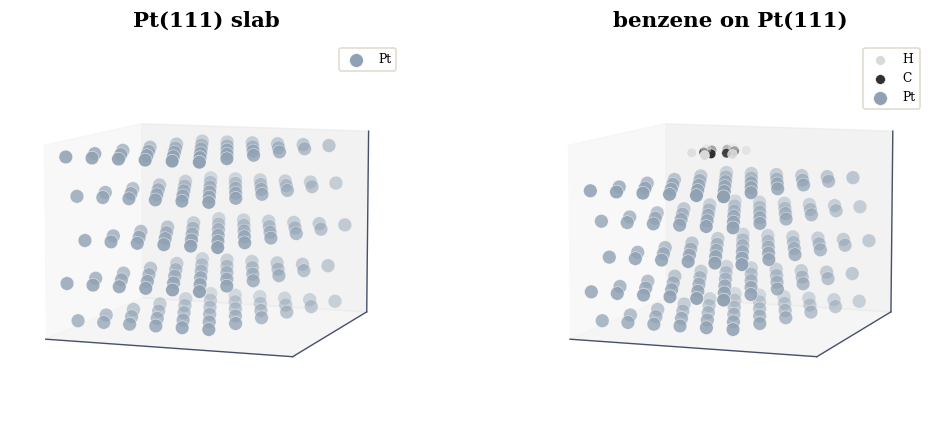

benzene sits 2.25 Å above the top Pt layer (180 Pt + 12 molecule atoms)


In [3]:
# (solution hidden on the public site)


### Validation 1 — a molecule above a surface

This must be a surface calculation: the molecule sits in the vacuum a couple of
ångström above the topmost platinum layer, not buried in it.

In [4]:
validate.check(
    1.5 < gap < 4.0,
    "benzene sits in the vacuum gap above the Pt surface",
    f"molecule-to-surface height = {gap:.2f} Å",
)

✓  benzene sits in the vacuum gap above the Pt surface   [molecule-to-surface height = 2.25 Å]


True

## Exercise 2 — The adsorption energy of benzene

The adsorption energy is the difference of three committed total-energy calculations
{eq}`eq-eads`: the bare slab, the isolated molecule, and the combined system. Below
are the course's committed totals (Hartree) for benzene on Pt(111). Their difference,
converted to eV, is the adsorption energy, and for benzene on Pt it should land near
the experimental value of about $-1.7\,$eV: benzene binds strongly, its whole
$\pi$-face in van der Waals contact with the metal.

**Part a)** Compute $E_{\rm ads}$ from the three totals. **Part b)** Confirm it
matches the measured benzene adsorption energy.

In [5]:
# (solution hidden on the public site)


E_ads(benzene) = (-21748.964 − -38.177 − -21710.724) Ha × 27.21
             = -1.70 eV   (experiment -1.72 eV)


### Validation 2 — benzene binds at the measured strength

The adsorption energy from the real totals must be bound (negative) and close to the
experimental $-1.7\,$eV.

In [6]:
validate.close(E_ads_benzene, E_ADS_EXP["benzene"], "the computed benzene adsorption energy matches experiment", atol=0.4)

✓  the computed benzene adsorption energy matches experiment   [got -1.70172 vs expected -1.72 (rtol=1e-06)]


True

## Exercise 3 — Functional sensitivity (Assignment 6)

Now the heart of the exercise. The course computed the adsorption energy of all three
hydrocarbons with two dispersion-aware methods, the **BEEF-vdW** functional and the
**Grimme D3** correction, and compared them to experiment. The result is sobering:
the two methods straddle the measured values, BEEF-vdW **underbinding** so badly that
it leaves methane and ethane *unbound* (positive adsorption energy), and Grimme D3
**overbinding** every molecule. The lesson is that for physisorption the dispersion
treatment, not just the functional, decides the answer.

**Part a)** Plot the adsorption energies of the three hydrocarbons for both methods
against experiment. **Part b)** Confirm dispersion is decisive: benzene binds most
strongly throughout, and the two methods bracket experiment.

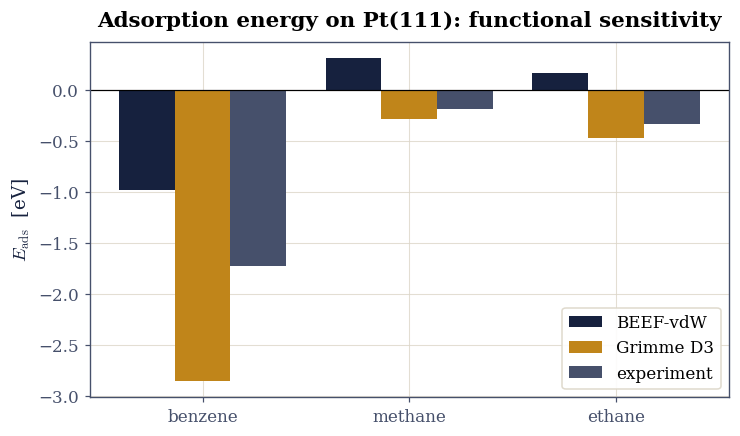

In [7]:
# (solution hidden on the public site)


### Validation 3 — dispersion is decisive, and benzene binds most

Two robust facts must hold: benzene is the most strongly bound species in every
method (its large $\pi$-face), and the two dispersion treatments bracket experiment
for benzene (BEEF-vdW above, Grimme D3 below), the signature of the functional
sensitivity.

In [8]:
benzene_strongest = all(E_ads[m][0] == E_ads[m].min() for m in ("Grimme D3", "BEEF-vdW", "experiment"))
brackets = E_ads["BEEF-vdW"][0] > E_ADS_EXP["benzene"] > E_ads["Grimme D3"][0]
validate.check(
    benzene_strongest and brackets,
    "benzene binds most strongly, and the two methods bracket experiment",
    f"benzene: BEEF-vdW {E_ads['BEEF-vdW'][0]}, exp {E_ADS_EXP['benzene']}, D3 {E_ads['Grimme D3'][0]} eV",
)

✓  benzene binds most strongly, and the two methods bracket experiment   [benzene: BEEF-vdW -0.975, exp -1.72, D3 -2.852 eV]


True

## Notebook summary

We computed the adsorption energies of benzene, methane, and ethane on Pt(111) from
the course's committed total energies. Benzene's $-1.70\,$eV from a real
calculation matched the measured value, and comparing the dispersion-aware methods
exposed the exercise's point: the BEEF-vdW functional underbinds so badly it leaves
the alkanes unbound, while the Grimme-D3 correction overbinds, the two bracketing
experiment. For physisorbed hydrocarbons it is the van der Waals treatment, not just
the functional, that decides the answer.

## Outlook

- **The deformation energy.** Splitting $E_{\rm ads}$ into the cost of distorting the
  molecule and slab into their adsorbed shapes plus the pure interaction separates
  geometry from binding.
- **Site dependence.** Repeating the calculation with the molecule over a top, bridge,
  or hollow site maps the corrugation of the surface potential.
- **Coverage.** Larger or smaller surface cells change the adsorbate-adsorbate
  spacing, giving the adsorption energy as a function of coverage.
- **Beyond pairwise dispersion.** Many-body dispersion (MBD) and the RPA go past the
  pairwise $-C_6/r^6$ picture and tend to improve metal-surface adsorption.

### References

```{bibliography}
:filter: docname in docnames
```

In [9]:
from ecp.style import footer

footer()

<ECP header: 1690 chars of HTML>